# Random Forest Training (10-Band + Spectral Indices)

This notebook trains **only Random Forest** on paired `*_img.tif` / `*_msk.tif` files.

Feature design (13 total):
- **10 spectral bands**: B2, B3, B4, B5, B6, B7, B8, B8A, B11, B12
- **3 spectral indices**: NDVI, NDBI, MNDWI — *physics-grounded separators for Greenery, Cement, Water*

Normalization: if 99th-percentile > 2.0 → divide by 10000 and clip [0, 1], else clip directly.

In [107]:
import importlib.util
import subprocess
import sys

def ensure_package(pkg_name):
    if importlib.util.find_spec(pkg_name) is None:
        print(f'Installing {pkg_name}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg_name])

ensure_package('scikit-image')
print('Package check complete.')

Installing scikit-image...
Package check complete.


In [ ]:
from pathlib import Path
import random
import warnings

import numpy as np
import rasterio
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import jaccard_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings('ignore')

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

PROJECT_DIR = Path.cwd().resolve()
if PROJECT_DIR.name == 'notebooks':
    PROJECT_DIR = PROJECT_DIR.parent

DATASET_DIR = PROJECT_DIR / 'data' / 'new_dataset'
TARGET_CLASSES = [1, 2, 3, 4]
CLASS_NAMES = {1: 'Greenery', 2: 'Sand', 3: 'Water', 4: 'Cement'}

# 10-band order in image TIFFs: [B2, B3, B4, B5, B6, B7, B8, B8A, B11, B12]
SPECTRAL_10_NAMES = ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12']
IDX_B2  = SPECTRAL_10_NAMES.index('B2')
IDX_B3  = SPECTRAL_10_NAMES.index('B3')
IDX_B4  = SPECTRAL_10_NAMES.index('B4')
IDX_B8  = SPECTRAL_10_NAMES.index('B8')
IDX_B8A = SPECTRAL_10_NAMES.index('B8A')
IDX_B11 = SPECTRAL_10_NAMES.index('B11')

EPS = 1e-6

image_paths = sorted(DATASET_DIR.glob('*_img.tif'))
mask_paths  = sorted(DATASET_DIR.glob('*_msk.tif'))

def sample_id(p: Path) -> str:
    return p.name.replace('_img.tif', '').replace('_msk.tif', '')

img_lookup = {sample_id(p): p for p in image_paths}
msk_lookup = {sample_id(p): p for p in mask_paths}
paired_ids = sorted(set(img_lookup) & set(msk_lookup))
pairs = [(img_lookup[sid], msk_lookup[sid]) for sid in paired_ids]

print(f'Dataset: {DATASET_DIR}')
print(f'Paired samples: {len(pairs)}')
print(f'Unmatched images: {len(set(img_lookup) - set(msk_lookup))}')
print(f'Unmatched masks:  {len(set(msk_lookup) - set(img_lookup))}')

Dataset: c:\satellite\project\new_dataset
Paired samples: 517
Unmatched images: 1
Unmatched masks:  0


In [109]:
# ── Helpers ────────────────────────────────────────────────────────────────────
def normalize_spectral_10(image_cube: np.ndarray) -> np.ndarray:
    spectral_raw = image_cube[:10].astype(np.float32)
    spectral_scale_probe = np.nanpercentile(spectral_raw, 99)
    if spectral_scale_probe > 2.0:
        spectral_norm = np.clip(spectral_raw / 10000.0, 0.0, 1.0)
    else:
        spectral_norm = np.clip(spectral_raw, 0.0, 1.0)
    return spectral_norm

def compute_spectral_indices(spectral_norm: np.ndarray) -> np.ndarray:
    """Return (6, H, W) array: NDVI, NDBI, MNDWI, BSI, DBI, NSI."""
    b2  = spectral_norm[IDX_B2]
    b3  = spectral_norm[IDX_B3]
    b4  = spectral_norm[IDX_B4]
    b8  = spectral_norm[IDX_B8]
    b8a = spectral_norm[IDX_B8A]
    b11 = spectral_norm[IDX_B11]
    ndvi  = (b8  - b4)  / (b8  + b4  + EPS)
    ndbi  = (b11 - b8)  / (b11 + b8  + EPS)
    mndwi = (b3  - b11) / (b3  + b11 + EPS)
    bsi   = ((b11 + b4) - (b8 + b2)) / ((b11 + b4) + (b8 + b2) + EPS)
    dbi   = ndbi - ndvi                            # Dry Built-up Index (urban)
    nsi   = (b11 - b8a) / (b11 + b8a + EPS)       # Normalized Sand Index
    return np.stack([ndvi, ndbi, mndwi, bsi, dbi, nsi], axis=0).astype(np.float32)

# 16 features total: 10 spectral + 6 indices
FEATURE_NAMES = SPECTRAL_10_NAMES + ['NDVI', 'NDBI', 'MNDWI', 'BSI', 'DBI', 'NSI']

print(f'Feature count: {len(FEATURE_NAMES)}')
print(FEATURE_NAMES)


Feature count: 16
['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12', 'NDVI', 'NDBI', 'MNDWI', 'BSI', 'DBI', 'NSI']


In [ ]:
def collect_stratified_pixels(
    paired_paths,
    target_per_class=300000,
    per_patch_cap=30000,
    seed=RANDOM_STATE
):
    rng = np.random.default_rng(seed)

    X_chunks = []
    y_chunks = []
    collected = {c: 0 for c in TARGET_CLASSES}

    order = np.arange(len(paired_paths))
    rng.shuffle(order)

    for idx in order:
        img_path, msk_path = paired_paths[idx]

        with rasterio.open(img_path) as src:
            image_cube = src.read().astype(np.float32)

        if image_cube.shape[0] < 10:
            raise ValueError(f'{img_path.name} has {image_cube.shape[0]} bands, expected at least 10.')

        with rasterio.open(msk_path) as src:
            mask = src.read(1).astype(np.int32)

        spectral_norm = normalize_spectral_10(image_cube)

        # --- 10 spectral bands ---
        spectral_flat = np.moveaxis(spectral_norm, 0, -1).reshape(-1, 10)

        # --- spectral indices ---
        index_maps = compute_spectral_indices(spectral_norm)               # (6, H, W)
        index_flat = np.moveaxis(index_maps, 0, -1).reshape(-1, 6)

        mask_flat = mask.reshape(-1)

        for cls in TARGET_CLASSES:
            remaining = target_per_class - collected[cls]
            if remaining <= 0:
                continue

            cls_idx = np.where(mask_flat == cls)[0]
            if cls_idx.size == 0:
                continue

            take   = min(remaining, per_patch_cap, cls_idx.size)
            chosen = rng.choice(cls_idx, size=take, replace=False)

            x_chunk = np.concatenate([
                spectral_flat[chosen],   # 10
                index_flat[chosen]       # 3
            ], axis=1).astype(np.float32)

            X_chunks.append(x_chunk)
            y_chunks.append(np.full(take, cls, dtype=np.int32))
            collected[cls] += int(take)

        if all(collected[c] >= target_per_class for c in TARGET_CLASSES):
            break

    if not X_chunks:
        raise RuntimeError('No samples collected. Check dataset paths/masks/classes.')

    X = np.vstack(X_chunks).astype(np.float32)
    y = np.concatenate(y_chunks).astype(np.int32)

    print('Collected per class:')
    for cls in TARGET_CLASSES:
        print(f'  {cls} ({CLASS_NAMES[cls]}): {collected[cls]:,}')
    if not all(collected[c] >= target_per_class for c in TARGET_CLASSES):
        print('Warning: at least one class did not reach target_per_class. Continuing with available pixels.')
    print(f'Total sampled pixels: {len(y):,}')

    return X, y

X, y = collect_stratified_pixels(
    pairs,
    target_per_class=250000,
    per_patch_cap=1000
)

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f'X_train: {X_train.shape} | X_val: {X_val.shape}')


Collected per class:
  1 (Greenery): 279,232
  2 (Sand): 300,000
  3 (Water): 300,000
  4 (Cement): 300,000
Total sampled pixels: 1,179,232
X_train: (943385, 16) | X_val: (235847, 16)


## PCA – Feature Exploration

Standardise all features, run PCA, then inspect:
- **Explained variance** per component (scree plot)
- **Feature loadings** heatmap – which features drive each PC
- **Ranked feature importance** by max absolute loading across the top PCs
- **PC1 vs PC2 scatter** coloured by class to check separability

Feature ranking (most influential → least influential):
   1. MNDWI                           max|loading|=0.708
   2. NDVI                            max|loading|=0.632
   3. NSI                             max|loading|=0.598
   4. BSI                             max|loading|=0.543
   5. B2                              max|loading|=0.503
   6. B12                             max|loading|=0.481
   7. NDBI                            max|loading|=0.465
   8. DBI                             max|loading|=0.425
   9. B11                             max|loading|=0.336
  10. B5                              max|loading|=0.321
  11. B8                              max|loading|=0.320
  12. B3                              max|loading|=0.314
  13. B4                              max|loading|=0.311
  14. B6                              max|loading|=0.301
  15. B7                              max|loading|=0.287
  16. B8A                             max|loading|=0.284


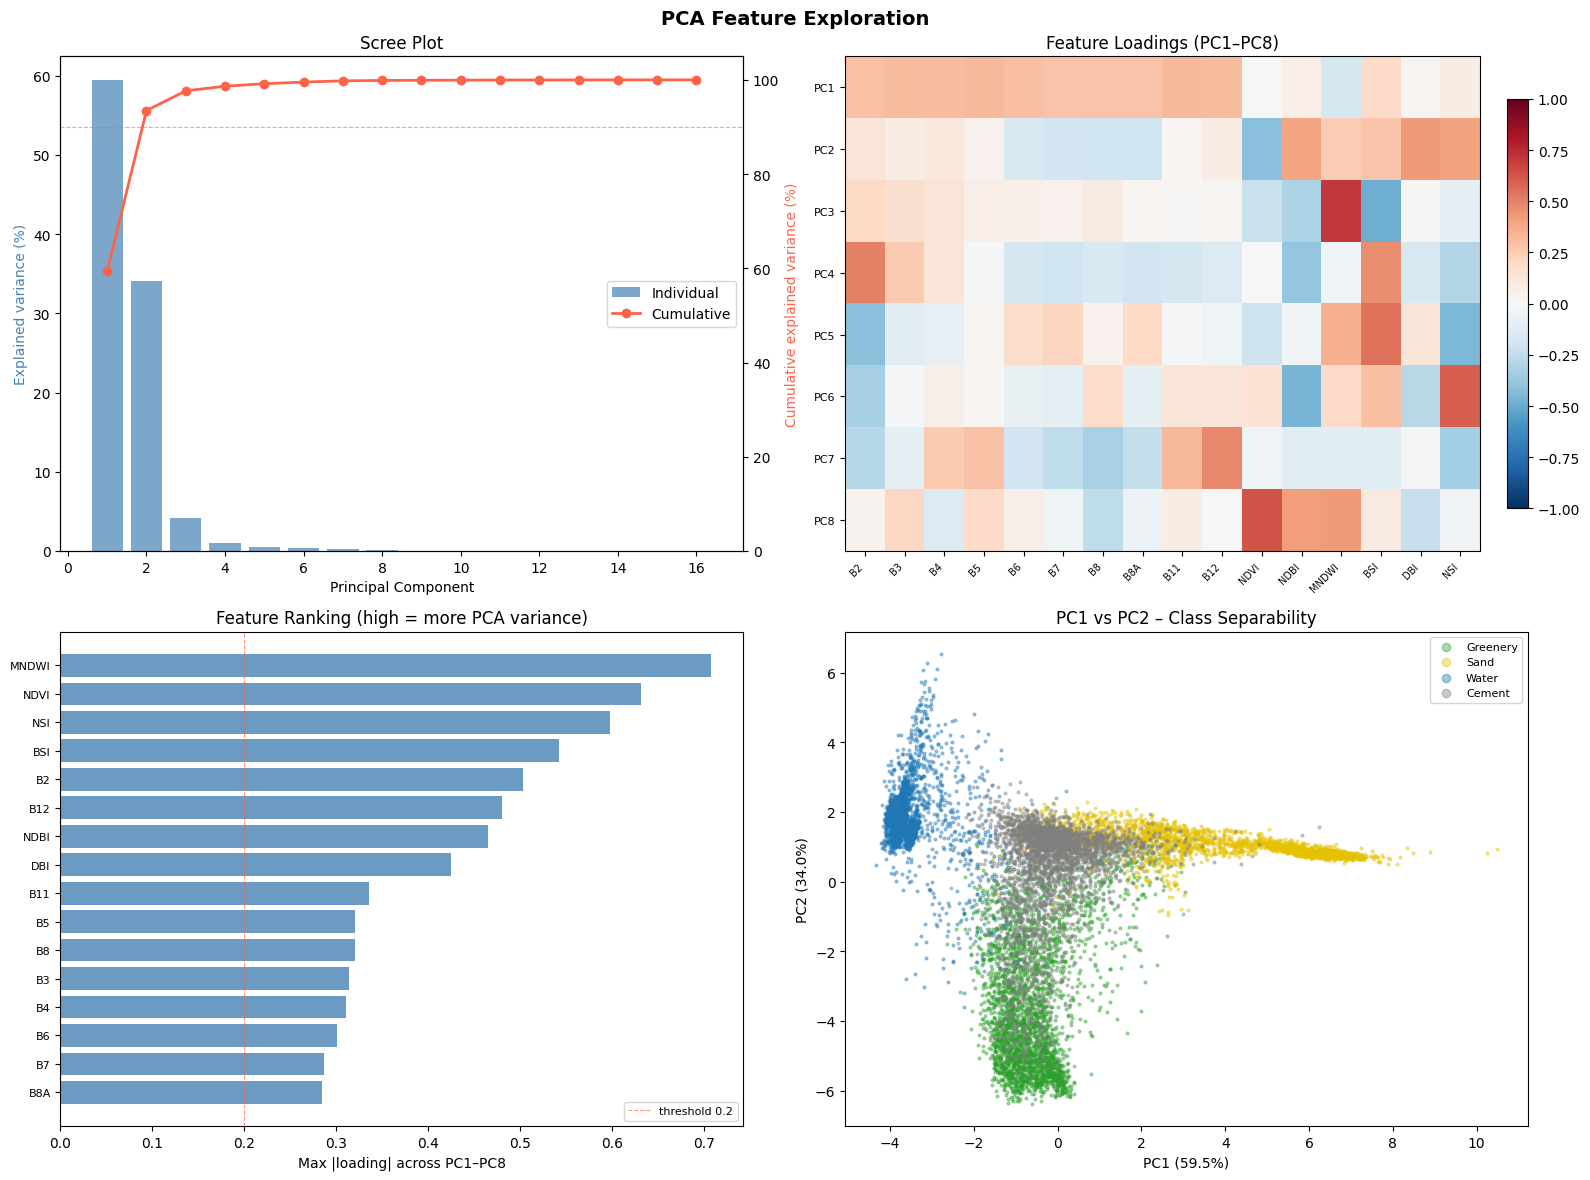

In [111]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# ── Standardise ────────────────────────────────────────────────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

# ── Fit full PCA ───────────────────────────────────────────────────────────────
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_scaled)

n_features = len(FEATURE_NAMES)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)

# ── Plot layout ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("PCA Feature Exploration", fontsize=14, fontweight="bold")

# --- 1. Scree / Cumulative Explained Variance ---
ax = axes[0, 0]
bars = ax.bar(range(1, n_features + 1), pca_full.explained_variance_ratio_ * 100,
              color="steelblue", alpha=0.7, label="Individual")
ax2 = ax.twinx()
ax2.plot(range(1, n_features + 1), cumvar * 100, "o-", color="tomato",
         linewidth=2, label="Cumulative")
ax2.axhline(90, color="tomato", linestyle="--", linewidth=0.8, alpha=0.6)
ax2.set_ylim(0, 105)
ax2.set_ylabel("Cumulative explained variance (%)", color="tomato")
ax.set_xlabel("Principal Component")
ax.set_ylabel("Explained variance (%)", color="steelblue")
ax.set_title("Scree Plot")
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc="center right")

# --- 2. Feature Loadings Heatmap (top 8 PCs) ---
N_PC = min(8, n_features)
loadings = pca_full.components_[:N_PC]          # shape (N_PC, n_features)
ax = axes[0, 1]
im = ax.imshow(loadings, aspect="auto", cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(n_features))
ax.set_xticklabels(FEATURE_NAMES, rotation=45, ha="right", fontsize=7)
ax.set_yticks(range(N_PC))
ax.set_yticklabels([f"PC{i+1}" for i in range(N_PC)], fontsize=8)
ax.set_title(f"Feature Loadings (PC1–PC{N_PC})")
plt.colorbar(im, ax=ax, fraction=0.03, pad=0.04)

# --- 3. Feature Importance by Max |Loading| across top PCs ---
max_abs_loading = np.max(np.abs(loadings), axis=0)   # shape (n_features,)
order = np.argsort(max_abs_loading)[::-1]
ax = axes[1, 0]
bars = ax.barh(range(n_features), max_abs_loading[order],
               color="steelblue", alpha=0.8)
ax.set_yticks(range(n_features))
ax.set_yticklabels([FEATURE_NAMES[i] for i in order], fontsize=8)
ax.invert_yaxis()
ax.set_xlabel(f"Max |loading| across PC1–PC{N_PC}")
ax.set_title("Feature Ranking (high = more PCA variance)")
ax.axvline(0.2, color="tomato", linestyle="--", linewidth=0.8, alpha=0.7,
           label="threshold 0.2")
ax.legend(fontsize=8)

print("Feature ranking (most influential → least influential):")
for rank, fi in enumerate(order, 1):
    marker = "  ← low influence" if max_abs_loading[fi] < 0.2 else ""
    print(f"  {rank:2d}. {FEATURE_NAMES[fi]:<30s}  max|loading|={max_abs_loading[fi]:.3f}{marker}")

# --- 4. PC1 vs PC2 scatter coloured by class ---
pca2 = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d = pca2.fit_transform(X_scaled)

ax = axes[1, 1]
palette = {0: "#888888", 1: "#2ca02c", 2: "#e5c100", 3: "#1f77b4", 4: "#7f7f7f"}
for cls_id, cls_name in CLASS_NAMES.items():
    mask_cls = y_train == cls_id
    if mask_cls.sum() == 0:
        continue
    # subsample for speed
    idx = np.where(mask_cls)[0]
    if len(idx) > 3000:
        idx = np.random.default_rng(RANDOM_STATE).choice(idx, 3000, replace=False)
    ax.scatter(X_2d[idx, 0], X_2d[idx, 1],
               s=4, alpha=0.4, label=cls_name,
               color=palette.get(cls_id, None))
ax.set_xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_title("PC1 vs PC2 – Class Separability")
ax.legend(markerscale=3, fontsize=8)

plt.tight_layout()
plt.show()


In [112]:
rf = RandomForestClassifier(
    n_estimators=206,
    max_depth=10,
    min_samples_split=8,
    min_samples_leaf=6,
    max_features='sqrt',
    bootstrap=True,
    n_jobs=-1,
    random_state=RANDOM_STATE
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_val)

iou_per_class = jaccard_score(
    y_val,
    y_pred,
    labels=TARGET_CLASSES,
    average=None,
    zero_division=0
)

val_miou = jaccard_score(
    y_val,
    y_pred,
    labels=TARGET_CLASSES,
    average='macro',
    zero_division=0
)

iou_by_class = {
    CLASS_NAMES[c]: float(iou_per_class[i])
    for i, c in enumerate(TARGET_CLASSES)
}

print('Validation IoU per class:')
for cls_name, cls_iou in iou_by_class.items():
    print(f'  {cls_name}: {cls_iou:.4f}')

print(f'Validation mIoU: {val_miou:.4f}')
print('Validation classification report:')
print(classification_report(y_val, y_pred, labels=TARGET_CLASSES, target_names=[CLASS_NAMES[c] for c in TARGET_CLASSES]))

Validation IoU per class:
  Greenery: 0.7709
  Sand: 0.8224
  Water: 0.9666
  Cement: 0.6567
Validation mIoU: 0.8041
Validation classification report:
              precision    recall  f1-score   support

    Greenery       0.84      0.90      0.87     55847
        Sand       0.94      0.87      0.90     60000
       Water       0.99      0.97      0.98     60000
      Cement       0.78      0.81      0.79     60000

    accuracy                           0.89    235847
   macro avg       0.89      0.89      0.89    235847
weighted avg       0.89      0.89      0.89    235847



In [113]:
#test on the train to check for overfitting
y_train_pred = rf.predict(X_train)

iou_per_class_train = jaccard_score(
    y_train,
    y_train_pred,
    labels=TARGET_CLASSES,
    average=None,
    zero_division=0
)

val_miou_train = jaccard_score(
    y_train,
    y_train_pred,
    labels=TARGET_CLASSES,
    average='macro',
    zero_division=0
)

print ('Train IoU per class:')
for cls_name, cls_iou in zip(CLASS_NAMES.values(), iou_per_class_train):
    print(f'  {cls_name}: {cls_iou:.4f}')
print(f'Train mIoU: {val_miou_train:.4f}')
print('Train classification report:')
print(classification_report(y_train, y_train_pred, labels=TARGET_CLASSES, target_names=[CLASS_NAMES[c] for c in TARGET_CLASSES]))

Train IoU per class:
  Greenery: 0.7725
  Sand: 0.8229
  Water: 0.9677
  Cement: 0.6583
Train mIoU: 0.8053
Train classification report:
              precision    recall  f1-score   support

    Greenery       0.84      0.90      0.87    223385
        Sand       0.94      0.87      0.90    240000
       Water       0.99      0.97      0.98    240000
      Cement       0.78      0.81      0.79    240000

    accuracy                           0.89    943385
   macro avg       0.89      0.89      0.89    943385
weighted avg       0.89      0.89      0.89    943385



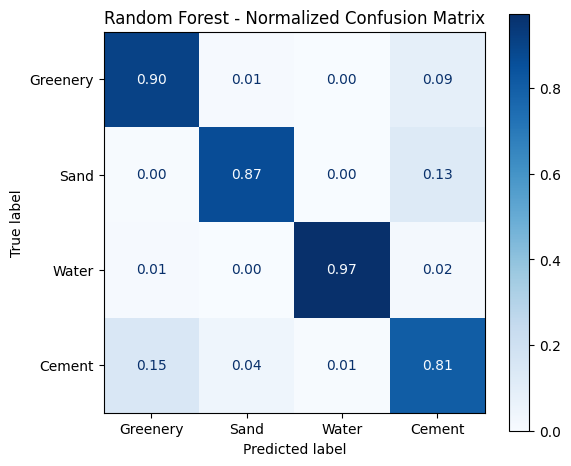

In [114]:
cm = confusion_matrix(y_val, y_pred, labels=TARGET_CLASSES, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[CLASS_NAMES[c] for c in TARGET_CLASSES])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues', values_format='.2f', colorbar=True)
plt.title('Random Forest - Normalized Confusion Matrix')
plt.tight_layout()
plt.show()

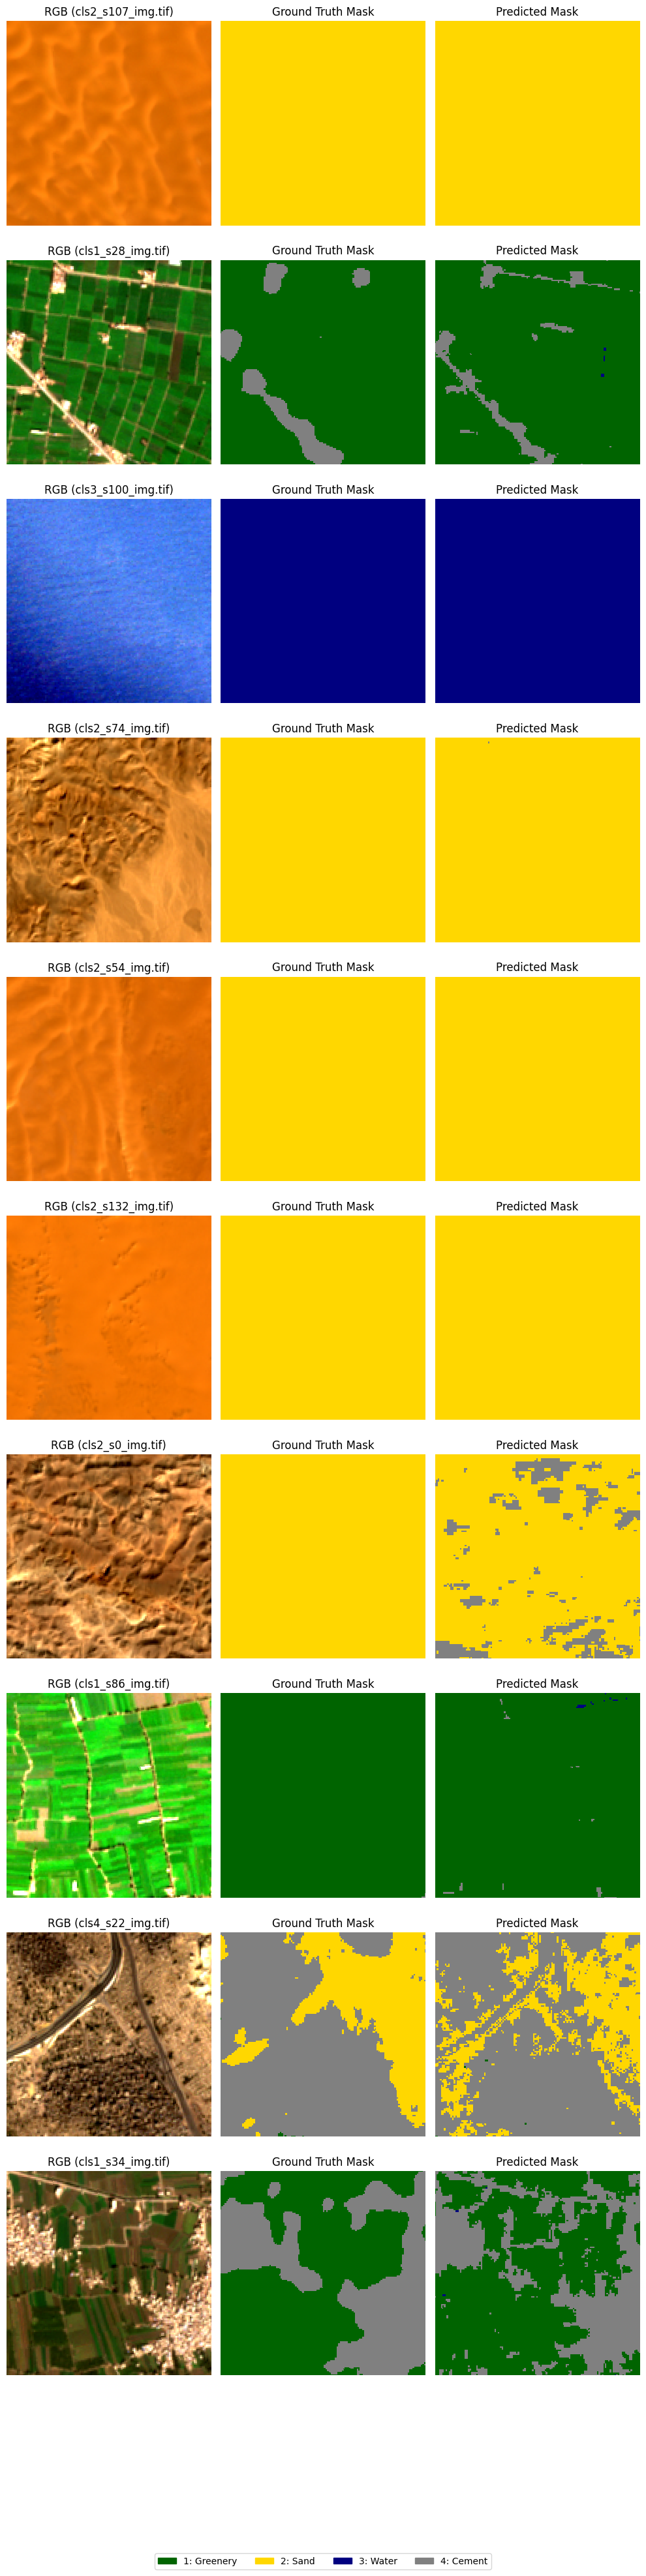

In [115]:
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap, BoundaryNorm

# Pick 3 random patches from the dataset for a qualitative check
vis_pairs = random.sample(pairs, min(10, len(pairs)))

CLASS_COLORS = {1: 'darkgreen', 2: 'gold', 3: 'navy', 4: 'gray'}
cmap_cls = ListedColormap([CLASS_COLORS[c] for c in TARGET_CLASSES])
bounds = np.arange(min(TARGET_CLASSES) - 0.5, max(TARGET_CLASSES) + 1.5, 1)
norm_cls = BoundaryNorm(bounds, ncolors=len(TARGET_CLASSES))
legend_patches = [mpatches.Patch(color=CLASS_COLORS[c], label=f'{c}: {CLASS_NAMES[c]}') for c in TARGET_CLASSES]

fig, axes = plt.subplots(len(vis_pairs), 3, figsize=(10, 4 * len(vis_pairs)))

if len(vis_pairs) == 1:
    axes = np.array([axes])

for row_idx, (img_path, msk_path) in enumerate(vis_pairs):
    with rasterio.open(img_path) as src:
        image_cube = src.read().astype(np.float32)
    with rasterio.open(msk_path) as src:
        mask = src.read(1).astype(np.int32)
        
    # Approximation for RGB visualization
    red = image_cube[IDX_B4]
    green = image_cube[IDX_B3]
    blue = image_cube[IDX_B2]
    rgb = np.stack([red, green, blue], axis=-1)
    p2, p98 = np.percentile(rgb, [2, 98])
    rgb = np.clip((rgb - p2) / (p98 - p2 + EPS), 0, 1)
    
    # Build features for prediction
    spectral_norm = normalize_spectral_10(image_cube)
    spectral_flat = np.moveaxis(spectral_norm, 0, -1).reshape(-1, 10)
    index_maps = compute_spectral_indices(spectral_norm)
    index_flat = np.moveaxis(index_maps, 0, -1).reshape(-1, 6)
    X_full = np.concatenate([spectral_flat, index_flat], axis=1).astype(np.float32)
    
    # Predict full image mask
    y_pred_full = rf.predict(X_full).reshape(mask.shape)
    
    axes[row_idx, 0].imshow(rgb)
    axes[row_idx, 0].set_title(f"RGB ({img_path.name})")
    axes[row_idx, 0].axis('off')
    
    axes[row_idx, 1].imshow(mask, cmap=cmap_cls, norm=norm_cls, interpolation='nearest')
    axes[row_idx, 1].set_title("Ground Truth Mask")
    axes[row_idx, 1].axis('off')
    
    axes[row_idx, 2].imshow(y_pred_full, cmap=cmap_cls, norm=norm_cls, interpolation='nearest')
    axes[row_idx, 2].set_title("Predicted Mask")
    axes[row_idx, 2].axis('off')

fig.legend(handles=legend_patches, loc='lower center', ncol=len(TARGET_CLASSES), bbox_to_anchor=(0.5, 0.01))
plt.tight_layout()
plt.subplots_adjust(bottom=0.08) # Make room for legend
plt.show()

In [116]:
import pickle

out_path = DATASET_DIR.parent / 'best_random_forest_10b_indices.pkl'
payload = {
    'model': rf,
    'model_type': 'random_forest',
    'feature_names': FEATURE_NAMES,
    'class_names': CLASS_NAMES,
    'validation_iou_per_class': iou_by_class,
    'validation_miou': val_miou,
    'config': {
    }
}

with open(out_path, 'wb') as f:
    pickle.dump(payload, f)

print(f'Saved: {out_path}')

Saved: c:\satellite\project\best_random_forest_10b_indices.pkl
